# Chapter 13 Exercises

These exercises turn the Chapter 13 sequence ideas into a small self-contained sentiment workflow. The focus is on padded batches, embeddings, a simple mean-pooled baseline, a packed GRU, and a toy embedding-space view.

## Setup

In [1]:
# !pip -q install torch matplotlib  # install dependencies if needed

import random

import matplotlib.pyplot as plt
import numpy as np
import torch
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from torch import nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_sequence
from torch.utils.data import DataLoader

plt.style.use("seaborn-v0_8")


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
PAD_IDX = 0
UNK_IDX = 1

train_examples = [
    ("love this soft shirt", 1),
    ("great fit and soft fabric", 1),
    ("very comfortable and warm", 1),
    ("perfect size and nice color", 1),
    ("happy with this cozy sweater", 1),
    ("stylish look and great quality", 1),
    ("lightweight jacket feels great", 1),
    ("these shoes are very comfortable", 1),
    ("hate this rough shirt", 0),
    ("bad fit and itchy fabric", 0),
    ("very tight and uncomfortable", 0),
    ("cheap material and poor stitching", 0),
    ("returned it after one wear", 0),
    ("small size and rough seams", 0),
    ("the color faded quickly", 0),
    ("this jacket feels stiff", 0),
]

val_examples = [
    ("love the warm fabric", 1),
    ("stylish and comfortable hoodie", 1),
    ("rough seams and bad fit", 0),
    ("cheap shirt feels itchy", 0),
]


def tokenize(text):
    return text.lower().split()


def build_vocab(examples):
    vocab = {PAD_TOKEN: PAD_IDX, UNK_TOKEN: UNK_IDX}
    for text, _ in examples:
        for token in tokenize(text):
            if token not in vocab:
                vocab[token] = len(vocab)
    return vocab


vocab = build_vocab(train_examples)


def encode(text):
    return [vocab.get(token, UNK_IDX) for token in tokenize(text)]


def collate_batch(batch):
    sequences = [torch.tensor(encode(text), dtype=torch.long) for text, _ in batch]
    lengths = torch.tensor([len(sequence) for sequence in sequences], dtype=torch.long)
    padded = pad_sequence(sequences, batch_first=True, padding_value=PAD_IDX)
    labels = torch.tensor([label for _, label in batch], dtype=torch.long)
    return padded, lengths, labels


train_loader = DataLoader(
    train_examples,
    batch_size=4,
    shuffle=True,
    generator=torch.Generator().manual_seed(42),
    collate_fn=collate_batch,
)
val_loader = DataLoader(val_examples, batch_size=4, shuffle=False, collate_fn=collate_batch)
criterion = nn.CrossEntropyLoss()


def evaluate_classifier(model, loader):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    with torch.no_grad():
        for token_ids, lengths, labels in loader:
            token_ids = token_ids.to(device)
            labels = labels.to(device)
            logits = model(token_ids, lengths)
            total_loss += criterion(logits, labels).item() * labels.size(0)
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_examples += labels.size(0)

    return total_loss / total_examples, total_correct / total_examples


def fit_classifier(model, train_loader, val_loader, *, epochs=30, lr=1e-2):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "val_acc": []}

    for _ in range(epochs):
        model.train()
        total_loss = 0.0
        total_examples = 0

        for token_ids, lengths, labels in train_loader:
            token_ids = token_ids.to(device)
            labels = labels.to(device)

            optimizer.zero_grad(set_to_none=True)
            logits = model(token_ids, lengths)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * labels.size(0)
            total_examples += labels.size(0)

        _, val_acc = evaluate_classifier(model, val_loader)
        history["train_loss"].append(total_loss / total_examples)
        history["val_acc"].append(val_acc)

    return history


def show_predictions(model, examples):
    padded, lengths, labels = collate_batch(examples)
    model.eval()
    with torch.no_grad():
        probs = model(padded.to(device), lengths).softmax(dim=1)[:, 1].cpu()

    for (text, label), prob in zip(examples, probs):
        pred = int(prob >= 0.5)
        print(f"{text:<32} | true={label} pred={pred} p(pos)={prob.item():.2f}")


print(f"Training examples: {len(train_examples)}, validation examples: {len(val_examples)}")
print(f"Vocabulary size: {len(vocab)}")

Using device: cpu
Training examples: 16, validation examples: 4
Vocabulary size: 51


## Exercise 1

Encode a few short sentences, pad them into one batch, and inspect the sequence lengths. Use one validation sentence to see how an unknown token falls back to `<unk>`.

In [2]:
demo_batch = [
    train_examples[0],
    train_examples[1],
    val_examples[1],
]

padded, lengths, labels = collate_batch(demo_batch)
for (text, label), ids, length in zip(demo_batch, padded.tolist(), lengths.tolist()):
    print(f"Text: {text}")
    print(f"Tokens: {tokenize(text)}")
    print(f"Encoded ids: {ids[:length]}")
    print(f"Length: {length}, label: {label}")
    print()

print(f"Padded batch shape: {tuple(padded.shape)}")
print(f"Sequence lengths: {lengths.tolist()}")
print(padded)
print()
print("Takeaway: padding lets one batch share a rectangular tensor, while the length tensor keeps track of the real sequence for each example.")

Text: love this soft shirt
Tokens: ['love', 'this', 'soft', 'shirt']
Encoded ids: [2, 3, 4, 5]
Length: 4, label: 1

Text: great fit and soft fabric
Tokens: ['great', 'fit', 'and', 'soft', 'fabric']
Encoded ids: [6, 7, 8, 4, 9]
Length: 5, label: 1

Text: stylish and comfortable hoodie
Tokens: ['stylish', 'and', 'comfortable', 'hoodie']
Encoded ids: [21, 8, 11, 1]
Length: 4, label: 1

Padded batch shape: (3, 5)
Sequence lengths: [4, 5, 4]
tensor([[ 2,  3,  4,  5,  0],
        [ 6,  7,  8,  4,  9],
        [21,  8, 11,  1,  0]])

Takeaway: padding lets one batch share a rectangular tensor, while the length tensor keeps track of the real sequence for each example.


## Exercise 2

Use an embedding layer on the padded batch, compute a masked mean sentence representation, then train a tiny mean-embedding sentiment classifier.

In [3]:
embedding = nn.Embedding(len(vocab), 3, padding_idx=PAD_IDX)
embedded = embedding(padded)
mask = (padded != PAD_IDX).unsqueeze(-1)
mean_vectors = (embedded * mask).sum(dim=1) / lengths.unsqueeze(1).to(embedded.dtype)

print(f"Embedding output shape: {tuple(embedded.shape)}")
print(f"Masked mean shape: {tuple(mean_vectors.shape)}")
print(f"Padding vector norm: {embedding.weight[PAD_IDX].norm().item():.4f}")
print()


class MeanEmbeddingClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.classifier = nn.Linear(embed_dim, 2)

    def forward(self, token_ids, lengths):
        embedded = self.embedding(token_ids)
        mask = (token_ids != PAD_IDX).unsqueeze(-1)
        summed = (embedded * mask).sum(dim=1)
        mean_embedding = summed / lengths.unsqueeze(1).to(embedded.dtype)
        return self.classifier(mean_embedding)


set_seed(42)
mean_model = MeanEmbeddingClassifier(len(vocab)).to(device)
mean_history = fit_classifier(mean_model, train_loader, val_loader, epochs=35, lr=0.03)
mean_val_loss, mean_val_acc = evaluate_classifier(mean_model, val_loader)

print(f"Mean-embedding validation accuracy: {mean_val_acc:.3f}")
show_predictions(mean_model, val_examples)
print()
print("Takeaway: averaging token embeddings gives a useful bag-of-words baseline, but it does not explicitly model token order.")

Embedding output shape: (3, 5, 3)
Masked mean shape: (3, 3)
Padding vector norm: 0.0000



Mean-embedding validation accuracy: 1.000
love the warm fabric             | true=1 pred=1 p(pos)=0.99
stylish and comfortable hoodie   | true=1 pred=1 p(pos)=0.78
rough seams and bad fit          | true=0 pred=0 p(pos)=0.00
cheap shirt feels itchy          | true=0 pred=0 p(pos)=0.00

Takeaway: averaging token embeddings gives a useful bag-of-words baseline, but it does not explicitly model token order.


## Exercise 3

Train a small GRU classifier with `pack_padded_sequence` and compare it with the mean-embedding baseline.

In [4]:
class GRUClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=12, hidden_dim=16):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.classifier = nn.Linear(hidden_dim, 2)

    def forward(self, token_ids, lengths):
        embedded = self.embedding(token_ids)
        packed = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        _, hidden = self.gru(packed)
        return self.classifier(hidden[-1])


demo_inputs, demo_lengths, _ = next(iter(train_loader))
print(f"Packed-GRU batch shape: {tuple(demo_inputs.shape)}")
print(f"Sequence lengths: {demo_lengths.tolist()}")
print()

set_seed(42)
gru_model = GRUClassifier(len(vocab)).to(device)
gru_history = fit_classifier(gru_model, train_loader, val_loader, epochs=40, lr=0.02)
gru_val_loss, gru_val_acc = evaluate_classifier(gru_model, val_loader)

print(f"Mean-embedding validation accuracy: {mean_val_acc:.3f}")
print(f"GRU validation accuracy: {gru_val_acc:.3f}")
show_predictions(gru_model, val_examples)
print()
print("Takeaway: the GRU reads tokens sequentially and uses the length tensor to ignore padded time steps cleanly.")

Packed-GRU batch shape: (4, 5)
Sequence lengths: [4, 5, 4, 5]

Mean-embedding validation accuracy: 1.000
GRU validation accuracy: 1.000
love the warm fabric             | true=1 pred=1 p(pos)=1.00
stylish and comfortable hoodie   | true=1 pred=1 p(pos)=1.00
rough seams and bad fit          | true=0 pred=0 p(pos)=0.00
cheap shirt feels itchy          | true=0 pred=0 p(pos)=0.00

Takeaway: the GRU reads tokens sequentially and uses the length tensor to ignore padded time steps cleanly.


## Exercise 4

Inspect the 3D embedding layer learned by the mean-embedding model and plot a few sentiment-heavy words.

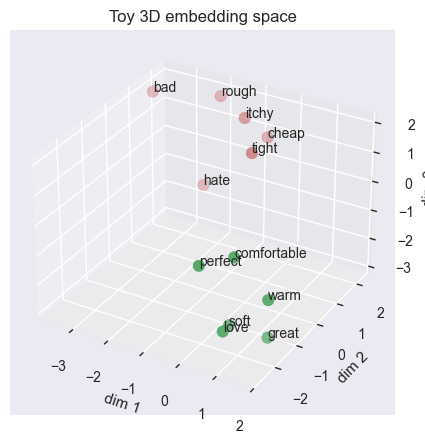

Takeaway: even in a toy setup, sentiment-heavy words often drift toward similar parts of the learned embedding space.


In [5]:
sentiment_words = [
    "love", "soft", "great", "comfortable", "warm", "perfect",
    "hate", "rough", "itchy", "bad", "cheap", "tight",
]
positive_words = {"love", "soft", "great", "comfortable", "warm", "perfect"}
word_points = torch.stack([
    mean_model.embedding.weight.detach().cpu()[vocab[word]]
    for word in sentiment_words
])
colors = ["#55A868" if word in positive_words else "#C44E52" for word in sentiment_words]

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(projection="3d")
ax.scatter(word_points[:, 0], word_points[:, 1], word_points[:, 2], c=colors, s=70)

for word, point in zip(sentiment_words, word_points):
    ax.text(point[0].item(), point[1].item(), point[2].item(), word)

ax.set_title("Toy 3D embedding space")
ax.set_xlabel("dim 1")
ax.set_ylabel("dim 2")
ax.set_zlabel("dim 3")
plt.show()

print("Takeaway: even in a toy setup, sentiment-heavy words often drift toward similar parts of the learned embedding space.")

## Summary

- Padding and sequence lengths work together: one makes batching possible, the other preserves the true sequence shape.
- Embeddings turn token ids into dense vectors that a model can average or process sequentially.
- A mean-embedding classifier is a simple baseline, while a GRU adds order-sensitive sequence processing.
- Small learned embeddings can be plotted directly to build intuition about what the model captured.